# Обучение и анализ моделей

**Шаг 6 плана.** Обучение нескольких моделей (Dummy, LogReg, XGBoost, LightGBM) для предсказания target (TP/SL). Temporal split по датам, выбор лучшей модели по Val AUC, подбор порога по Val F1, сохранение артефакта для бектеста.

## 1. Импорты и загрузка

**Что загружаем:**
- `data_labeled_tp_sl_1_05.parquet` — размеченные данные (target = TP или SL по барам).
- `scaler_tp_sl_1_05.joblib` — scaler и список фичей (уже отобранных в 07/08).

**Temporal split (по датам):** вместо случайного разбиения по сессиям используем хронологию — train на прошлом, val и test на будущем. Нет look-ahead.

In [7]:
import sys
import os
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

_root = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) in ('01_data_prep','02_targets','03_features','04_models','05_experiments') else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
try:
    import catboost as cb
    HAS_CB = True
except ImportError:
    HAS_CB = False

parquet_path = os.path.join(_root, 'outputs', 'data_labeled_tp_sl_1_05.parquet')
scaler_path = os.path.join(_root, 'models', 'scaler_tp_sl_1_05.joblib')
if not os.path.exists(parquet_path):
    raise FileNotFoundError(f'Файл не найден: {parquet_path}. Запустите 04_Data_Labeling_And_Feature_Loading.ipynb')
if not os.path.exists(scaler_path):
    raise FileNotFoundError(f'Файл не найден: {scaler_path}. Запустите 07_Scaling_And_Normalization.ipynb')

df = pd.read_parquet(parquet_path)
loaded = __import__('joblib').load(scaler_path)
FEATURES_SELECTED = loaded['features']
scaler = loaded['scaler']
TARGET_COL = loaded.get('target', 'target')

missing = [c for c in FEATURES_SELECTED if c not in df.columns]
if missing:
    raise ValueError(f'В датасете отсутствуют колонки из scaler features: {missing}')

valid = df.dropna(subset=FEATURES_SELECTED + [TARGET_COL]).copy()
valid = valid[valid[TARGET_COL].isin([-1.0, 1.0])]
valid['y'] = (valid[TARGET_COL] == 1).astype(int)
valid['date'] = pd.to_datetime(valid['datetime'], utc=True).dt.date

dates = sorted(valid['date'].unique())
# Temporal split: train 8 дней, val 1 день, test 1 день
train_dates = set(dates[:8])
val_dates = set([dates[8]])
test_dates = set([dates[9]])

train_df = valid[valid['date'].isin(train_dates)]
val_df = valid[valid['date'].isin(val_dates)]
test_df = valid[valid['date'].isin(test_dates)]

X_train = scaler.transform(train_df[FEATURES_SELECTED].fillna(0))
X_val = scaler.transform(val_df[FEATURES_SELECTED].fillna(0))
X_test = scaler.transform(test_df[FEATURES_SELECTED].fillna(0))
y_train, y_val, y_test = train_df['y'].values, val_df['y'].values, test_df['y'].values

print(f'Target: {TARGET_COL}, features: {len(FEATURES_SELECTED)}')
print(f'Temporal split: train={min(train_dates)}..{max(train_dates)} ({len(train_df):,}) | val={dates[8]} ({len(val_df):,}) | test={dates[9]} ({len(test_df):,})')
print(f'XGBoost: {HAS_XGB}, LightGBM: {HAS_LGB}, CatBoost: {HAS_CB}')

Target: target, features: 22
Temporal split: train=2026-02-01..2026-02-08 (147,527) | val=2026-02-09 (24,118) | test=2026-02-10 (15,459)
XGBoost: True, LightGBM: True, CatBoost: True


## 2. Обучение моделей

**Зачем несколько моделей:** сравнить baseline (Dummy, LogReg) и бустинги (XGBoost, LightGBM, CatBoost). Dummy — нижняя граница; LogReg — линейная; GBDT обычно даёт лучший AUC при наличии нелинейных зависимостей.

In [8]:
models = {}
models['Dummy'] = DummyClassifier(strategy='stratified', random_state=42).fit(X_train, y_train)
models['LogReg'] = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)
if HAS_XGB:
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        eval_metric='logloss'
    ).fit(X_train, y_train)
if HAS_LGB:
    models['LightGBM'] = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    ).fit(X_train, y_train)
if HAS_CB:
    models['CatBoost'] = cb.CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        random_seed=42,
        verbose=0
    ).fit(X_train, y_train)

print('Модели обучены:', list(models.keys()))

Модели обучены: ['Dummy', 'LogReg', 'XGBoost', 'LightGBM', 'CatBoost']


## 3. Метрики

**Почему выбор по Val AUC, а не Test:** тест используем только для финальной оценки. Выбор модели и гиперпараметров — по val, чтобы не переобучиться на test.

**Метрики:** AUC (разделимость классов), F1 (баланс precision/recall), Accuracy.

In [9]:
results = []
for name, m in models.items():
    proba_val = m.predict_proba(X_val)[:, 1]
    proba_test = m.predict_proba(X_test)[:, 1]
    pred_val = (proba_val >= 0.5).astype(int)
    pred_test = (proba_test >= 0.5).astype(int)

    auc_val = roc_auc_score(y_val, proba_val) if len(np.unique(y_val)) > 1 else 0.5
    auc_test = roc_auc_score(y_test, proba_test) if len(np.unique(y_test)) > 1 else 0.5
    f1_val = f1_score(y_val, pred_val)
    f1_test = f1_score(y_test, pred_test)
    acc_test = accuracy_score(y_test, pred_test)

    results.append({
        'model': name,
        'AUC_val': auc_val,
        'AUC_test': auc_test,
        'F1_val@0.5': f1_val,
        'F1_test@0.5': f1_test,
        'Accuracy_test@0.5': acc_test
    })

res_df = pd.DataFrame(results).sort_values('AUC_val', ascending=False)
print('Метрики (выбор модели по Val AUC):')
print(res_df.to_string(index=False))

Метрики (выбор модели по Val AUC):
   model  AUC_val  AUC_test  F1_val@0.5  F1_test@0.5  Accuracy_test@0.5
 XGBoost 0.757323  0.625873    0.694994     0.607200           0.589236
LightGBM 0.757003  0.628348    0.691890     0.609245           0.592082
CatBoost 0.752042  0.625148    0.683173     0.612994           0.589236
  LogReg 0.722197  0.613119    0.662823     0.595853           0.577657
   Dummy 0.502851  0.491891    0.511190     0.512215           0.492399


## 4. Classification report и confusion matrix (лучшая модель)

**Порог 0.5 vs tuned:** по умолчанию pred=1 при proba≥0.5. Подбор порога по Val F1 в диапазоне **0.45–0.90** (шаг 0.01) — чтобы захватить продовый порог 0.8 и сравнить поведение до 0.9. Лучший порог сохраняется в артефакт.

**Вывод:** смотрим precision/recall по классам и confusion matrix — важно понимать, больше ли мы ошибаемся в сторону false BUY или false SELL.

In [10]:
best_name = res_df.iloc[0]['model']
best_model = models[best_name]

# Подбор порога на validation (максимум F1), расширенный диапазон 0.45–0.90 (в т.ч. продовый 0.8)
val_proba = best_model.predict_proba(X_val)[:, 1]
test_proba = best_model.predict_proba(X_test)[:, 1]
thresholds = np.round(np.arange(0.45, 0.91, 0.01), 2)
best_thr, best_f1 = 0.5, -1.0
for thr in thresholds:
    f1 = f1_score(y_val, (val_proba >= thr).astype(int))
    if f1 > best_f1:
        best_f1 = f1
        best_thr = float(thr)

pred_test_05 = (test_proba >= 0.5).astype(int)
pred_test_best = (test_proba >= best_thr).astype(int)

# Таблица по ключевым порогам (0.45 — начало поиска, в т.ч. продовый 0.8)
key_thr = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
thr_rows = []
for t in key_thr:
    pv = (val_proba >= t).astype(int)
    pt = (test_proba >= t).astype(int)
    thr_rows.append({
        'thr': t, 'F1_val': f1_score(y_val, pv), 'F1_test': f1_score(y_test, pt),
        'Acc_val': accuracy_score(y_val, pv), 'Acc_test': accuracy_score(y_test, pt)
    })
thr_df = pd.DataFrame(thr_rows)
print(f'Лучшая модель по Val AUC: {best_name}')
print('\nМетрики по порогам (для сравнения, в т.ч. прод 0.8):')
print(thr_df.round(4).to_string(index=False))

print(f'\nЛучший порог по Val F1: {best_thr:.2f} (F1_val={best_f1:.4f})')
print('\nClassification report (test, tuned threshold):')
print(classification_report(y_test, pred_test_best, target_names=['SELL', 'BUY']))
print('Confusion matrix (test, tuned threshold):')
print(confusion_matrix(y_test, pred_test_best))
print(f"Test AUC: {roc_auc_score(y_test, test_proba):.4f}")
print(f"Test F1@0.5: {f1_score(y_test, pred_test_05):.4f} | Test F1@{best_thr:.2f}: {f1_score(y_test, pred_test_best):.4f}")

Лучшая модель по Val AUC: XGBoost

Метрики по порогам (для сравнения, в т.ч. прод 0.8):
 thr  F1_val  F1_test  Acc_val  Acc_test
0.45  0.7177   0.6528   0.6706    0.5923
0.50  0.6950   0.6072   0.6827    0.5892
0.55  0.6455   0.5401   0.6751    0.5767
0.60  0.5631   0.4492   0.6492    0.5583
0.65  0.4609   0.3369   0.6174    0.5334
0.70  0.3422   0.2349   0.5801    0.5145
0.75  0.2328   0.1438   0.5469    0.4969
0.80  0.1418   0.0736   0.5203    0.4822
0.85  0.0747   0.0368   0.5019    0.4755
0.90  0.0265   0.0125   0.4891    0.4695

Лучший порог по Val F1: 0.45 (F1_val=0.7177)

Classification report (test, tuned threshold):
              precision    recall  f1-score   support

        SELL       0.58      0.45      0.51      7210
         BUY       0.60      0.72      0.65      8249

    accuracy                           0.59     15459
   macro avg       0.59      0.58      0.58     15459
weighted avg       0.59      0.59      0.58     15459

Confusion matrix (test, tuned threshold)

**Интерпретация метрик (по выводу выше):**
- AUC_val > AUC_test — нормально: val ближе к train по времени.
- Precision/Recall: если precision(BUY) выше recall(BUY) — модель осторожнее с BUY (меньше ложных сигналов, но пропускает часть).
- Confusion matrix: строки = факт (SELL/BUY), столбцы = предсказание. Диагональ — правильно, off-diagonal — ошибки.

## 5. ROC-curves

ROC: TPR vs FPR при разных порогах. AUC = площадь под кривой. Чем выше кривая над диагональю — тем лучше модель отделяет BUY от SELL.

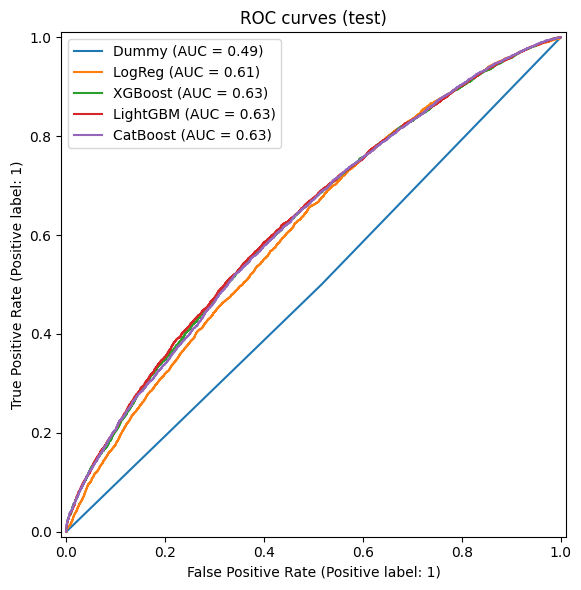

In [11]:
try:
    from sklearn.metrics import RocCurveDisplay
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, m in models.items():
        proba = m.predict_proba(X_test)[:, 1]
        RocCurveDisplay.from_predictions(y_test, proba, ax=ax, name=name)
    plt.title('ROC curves (test)')
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib не установлен — пропуск ROC')

## 6. Сохранение лучшей модели

Артефакт: model, scaler, features, target, threshold (подобран по val), val_auc, test_auc, split info. Сохраняется в `candidate_baseline_tp_sl_1_05.joblib` (кандидат по Val AUC для бэктеста в 08 и экспериментов 13–15; прод — NB16).

In [12]:
import joblib

os.makedirs(os.path.join(_root, 'models'), exist_ok=True)
val_auc = float(res_df.loc[res_df['model'] == best_name, 'AUC_val'].iloc[0])
test_auc = float(res_df.loc[res_df['model'] == best_name, 'AUC_test'].iloc[0])
artifact = {
    'model': best_model,
    'model_name': best_name,
    'scaler': scaler,
    'features': FEATURES_SELECTED,
    'target': TARGET_COL,
    'threshold': best_thr,
    'val_auc': val_auc,
    'test_auc': test_auc,
    'split': {'type': 'temporal', 'train_days': 8, 'val_days': 1, 'test_days': 1, 'test_date': str(dates[9])}
}

path_candidate = os.path.join(_root, 'models', 'candidate_baseline_tp_sl_1_05.joblib')
joblib.dump(artifact, path_candidate)

print(f'Сохранено: {path_candidate} ({best_name}, val_auc={val_auc:.4f}, test_auc={test_auc:.4f}, thr={best_thr:.2f})')

Сохранено: c:\project\trading_bot_2Engine\models\best_model_tp_sl_1_05.joblib (XGBoost, val_auc=0.7573, test_auc=0.6259, thr=0.45)
Обновлён совместимый путь: c:\project\trading_bot_2Engine\models\best_model.joblib


## Итог шага 6

| Этап | Что сделано |
|------|-------------|
| Split | Temporal: train 8 дней, val 1 день, test 1 день. Тест = последний день, модель его не видела. |
| Модели | Dummy, LogReg, XGBoost, LightGBM, CatBoost (если есть). |
| Выбор | По **AUC_val** — не по test, чтобы не переобучиться. |
| Порог | По **Val F1** в диапазоне 0.45–0.90 (в т.ч. прод 0.8). Сохраняется в артефакт. |
| Артефакт | `candidate_baseline_tp_sl_1_05.joblib` — кандидат для бэктеста в 08 и экспериментов 13–15. |

**Важно:** Val AUC часто выше Test AUC (val ближе по времени к train). Test AUC — честная оценка на «будущем» дне.